# 特征工程进阶 - 特征创建和转换

本笔记本演示如何创建新特征和进行特征转换。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

plt.rcParams['font.sans-serif'] = ['KaiTi']  # 楷体字
plt.rcParams['axes.unicode_minus'] = False
print("特征创建和转换库已导入")

特征创建和转换库已导入


## 1. 数学变换特征

In [2]:
# 创建示例数据
data = pd.DataFrame({
    '销售额': [100, 150, 200, 250, 300, 350, 400],
    '访问量': [1000, 1500, 2000, 2500, 3000, 3500, 4000]
})

print("原始数据:")
print(data)
print()

原始数据:
   销售额   访问量
0  100  1000
1  150  1500
2  200  2000
3  250  2500
4  300  3000
5  350  3500
6  400  4000



In [3]:
# 创建新特征 - 数学变换
print("创建数学变换特征:")

# 对数变换
data['销售额_log'] = np.log1p(data['销售额'])  # log1p = log(1 + x)

# 平方
data['销售额_square'] = data['销售额'] ** 2

# 平方根
data['访问量_sqrt'] = np.sqrt(data['访问量'])

# 倒数
data['销售额_reciprocal'] = 1 / (data['销售额'] + 1)

print(data[['销售额', '销售额_log', '销售额_square', '销售额_reciprocal']])
print()

创建数学变换特征:
   销售额   销售额_log  销售额_square  销售额_reciprocal
0  100  4.615121       10000        0.009901
1  150  5.017280       22500        0.006623
2  200  5.303305       40000        0.004975
3  250  5.525453       62500        0.003984
4  300  5.707110       90000        0.003322
5  350  5.860786      122500        0.002849
6  400  5.993961      160000        0.002494



## 2. 交互特征和比率特征

In [4]:
# 创建交互特征
print("创建交互特征和比率特征:")

# 交互特征
data['销售额_访问量_交互'] = data['销售额'] * data['访问量']

# 比率特征
data['转化率'] = data['销售额'] / data['访问量']

print(data[['销售额', '访问量', '销售额_访问量_交互', '转化率']])

创建交互特征和比率特征:
   销售额   访问量  销售额_访问量_交互  转化率
0  100  1000      100000  0.1
1  150  1500      225000  0.1
2  200  2000      400000  0.1
3  250  2500      625000  0.1
4  300  3000      900000  0.1
5  350  3500     1225000  0.1
6  400  4000     1600000  0.1


## 3. 多项式特征

In [5]:
# 使用 PolynomialFeatures 创建多项式特征
X = data[['销售额', '访问量']].values[:3]  # 取前3行作为示例

print("原始特征:")
print(X)
print()

# 创建 2 阶多项式特征
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print("2 阶多项式特征:")
feature_names = poly.get_feature_names_out(['销售额', '访问量'])
poly_df = pd.DataFrame(X_poly, columns=feature_names)
print(poly_df)
print()
print(f"原始特征数: {X.shape[1]}, 多项式特征数: {X_poly.shape[1]}")

原始特征:
[[ 100 1000]
 [ 150 1500]
 [ 200 2000]]

2 阶多项式特征:
     销售额     访问量    销售额^2   销售额 访问量      访问量^2
0  100.0  1000.0  10000.0  100000.0  1000000.0
1  150.0  1500.0  22500.0  225000.0  2250000.0
2  200.0  2000.0  40000.0  400000.0  4000000.0

原始特征数: 2, 多项式特征数: 5


## 4. 时间特征提取

In [6]:
# 创建时间序列数据
dates = pd.date_range('2024-01-01', periods=10, freq='D')
df_time = pd.DataFrame({
    '日期': dates,
    '销售额': np.random.randint(100, 500, 10)
})

print("原始时间数据:")
print(df_time)
print()

原始时间数据:
          日期  销售额
0 2024-01-01  323
1 2024-01-02  392
2 2024-01-03  106
3 2024-01-04  145
4 2024-01-05  275
5 2024-01-06  484
6 2024-01-07  290
7 2024-01-08  261
8 2024-01-09  168
9 2024-01-10  395



In [7]:
# 提取时间特征
print("提取时间特征:")

df_time['年'] = df_time['日期'].dt.year
df_time['月'] = df_time['日期'].dt.month
df_time['日'] = df_time['日期'].dt.day
df_time['星期'] = df_time['日期'].dt.dayofweek  # 0=Monday, 6=Sunday
df_time['是否周末'] = df_time['星期'].isin([5, 6]).astype(int)
df_time['季度'] = df_time['日期'].dt.quarter
df_time['周数'] = df_time['日期'].dt.isocalendar().week

print(df_time[['日期', '销售额', '年', '月', '日', '星期', '是否周末', '季度']])

提取时间特征:
          日期  销售额     年  月   日  星期  是否周末  季度
0 2024-01-01  323  2024  1   1   0     0   1
1 2024-01-02  392  2024  1   2   1     0   1
2 2024-01-03  106  2024  1   3   2     0   1
3 2024-01-04  145  2024  1   4   3     0   1
4 2024-01-05  275  2024  1   5   4     0   1
5 2024-01-06  484  2024  1   6   5     1   1
6 2024-01-07  290  2024  1   7   6     1   1
7 2024-01-08  261  2024  1   8   0     0   1
8 2024-01-09  168  2024  1   9   1     0   1
9 2024-01-10  395  2024  1  10   2     0   1


## 5. 分箱（Binning）

In [8]:
# 创建年龄数据
ages = pd.DataFrame({
    '年龄': [5, 15, 25, 35, 45, 55, 65, 75]
})

print("原始数据:")
print(ages)
print()

原始数据:
   年龄
0   5
1  15
2  25
3  35
4  45
5  55
6  65
7  75



In [9]:
# 等频分箱
print("等频分箱 (qcut):")
ages['年龄_分箱_等频'] = pd.qcut(ages['年龄'], q=3, labels=['年轻', '中年', '老年'])
print(ages)
print()

等频分箱 (qcut):
   年龄 年龄_分箱_等频
0   5       年轻
1  15       年轻
2  25       年轻
3  35       中年
4  45       中年
5  55       老年
6  65       老年
7  75       老年



In [10]:
# 等宽分箱
print("等宽分箱 (cut):")
ages['年龄_分箱_等宽'] = pd.cut(ages['年龄'], 
                            bins=[0, 18, 35, 60, 100],
                            labels=['儿童', '青年', '成年', '老年'])
print(ages[['年龄', '年龄_分箱_等频', '年龄_分箱_等宽']])

等宽分箱 (cut):
   年龄 年龄_分箱_等频 年龄_分箱_等宽
0   5       年轻       儿童
1  15       年轻       儿童
2  25       年轻       青年
3  35       中年       青年
4  45       中年       成年
5  55       老年       成年
6  65       老年       老年
7  75       老年       老年


## 6. PCA 降维

In [11]:
# 创建高维数据
np.random.seed(42)
X_high = np.random.randn(100, 5)

print(f"原始数据维度: {X_high.shape}")
print()

原始数据维度: (100, 5)



In [12]:
# 应用 PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_high)

print(f"PCA 后的维度: {X_pca.shape}")
print()

# 解释方差比
print(f"各主成分解释方差比: {pca.explained_variance_ratio_}")
print(f"累计解释方差比: {np.cumsum(pca.explained_variance_ratio_)}")
print(f"总共解释方差: {pca.explained_variance_ratio_.sum():.2%}")

PCA 后的维度: (100, 2)

各主成分解释方差比: [0.26256655 0.21579693]
累计解释方差比: [0.26256655 0.47836348]
总共解释方差: 47.84%


In [13]:
# 显示 PCA 结果
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

print("\nPCA 降维后的数据 (前10行):")
print(pca_df.head(10))


PCA 降维后的数据 (前10行):
        PC1       PC2
0  0.003030  0.598824
1  1.286832  0.957901
2 -1.665495  0.605003
3 -1.436314  0.283083
4 -1.315364  0.030846
5 -0.824512 -0.354225
6  1.446679  0.421064
7 -0.087107 -1.333475
8 -1.413918  0.807804
9 -0.972778  1.380714


## 7. 特征创建可视化

C:\Users\zhang\AppData\Local\Temp\ipykernel_18656\986804966.py:41: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) KaiTi.
  plt.tight_layout()
d:\Programs\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) KaiTi.
  fig.canvas.print_figure(bytes_io, **kw)


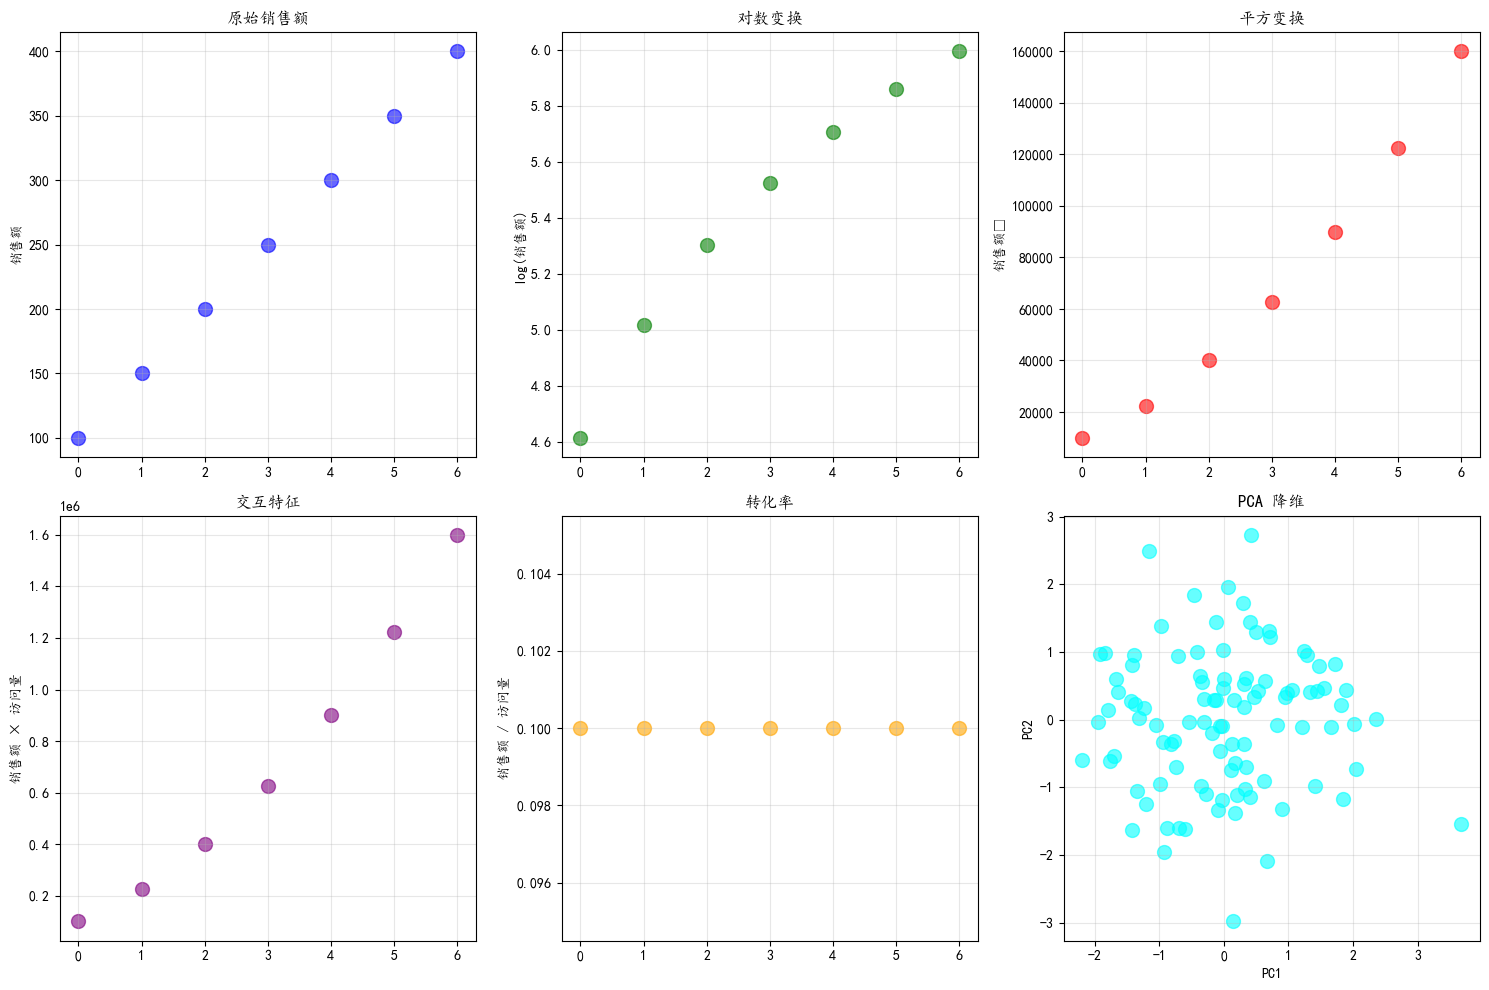

In [14]:
# 绘制原始特征 vs 变换特征
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 原始销售额
axes[0, 0].scatter(range(len(data)), data['销售额'], s=100, alpha=0.6, color='blue')
axes[0, 0].set_title('原始销售额')
axes[0, 0].set_ylabel('销售额')
axes[0, 0].grid(True, alpha=0.3)

# 对数变换
axes[0, 1].scatter(range(len(data)), data['销售额_log'], s=100, alpha=0.6, color='green')
axes[0, 1].set_title('对数变换')
axes[0, 1].set_ylabel('log(销售额)')
axes[0, 1].grid(True, alpha=0.3)

# 平方
axes[0, 2].scatter(range(len(data)), data['销售额_square'], s=100, alpha=0.6, color='red')
axes[0, 2].set_title('平方变换')
axes[0, 2].set_ylabel('销售额²')
axes[0, 2].grid(True, alpha=0.3)

# 交互特征
axes[1, 0].scatter(range(len(data)), data['销售额_访问量_交互'], s=100, alpha=0.6, color='purple')
axes[1, 0].set_title('交互特征')
axes[1, 0].set_ylabel('销售额 × 访问量')
axes[1, 0].grid(True, alpha=0.3)

# 转化率
axes[1, 1].scatter(range(len(data)), data['转化率'], s=100, alpha=0.6, color='orange')
axes[1, 1].set_title('转化率')
axes[1, 1].set_ylabel('销售额 / 访问量')
axes[1, 1].grid(True, alpha=0.3)

# PCA 结果
axes[1, 2].scatter(X_pca[:, 0], X_pca[:, 1], s=100, alpha=0.6, color='cyan')
axes[1, 2].set_title('PCA 降维')
axes[1, 2].set_xlabel('PC1')
axes[1, 2].set_ylabel('PC2')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

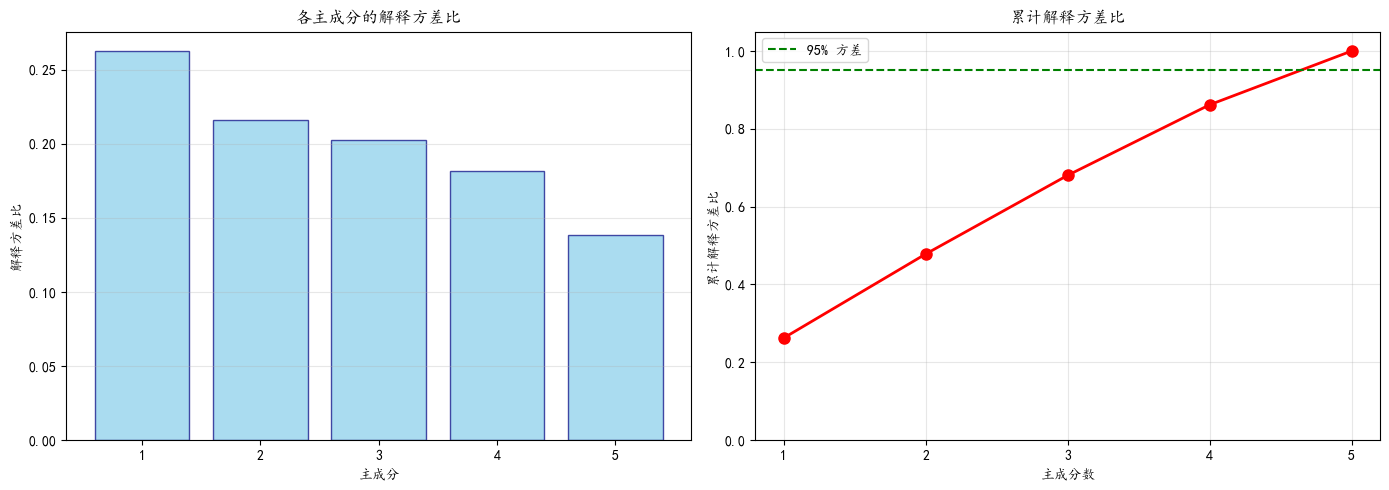

In [15]:
# 绘制 PCA 解释方差
pca_full = PCA()
pca_full.fit(X_high)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 各主成分解释方差比
axes[0].bar(range(1, 6), pca_full.explained_variance_ratio_, alpha=0.7, color='skyblue', edgecolor='navy')
axes[0].set_xlabel('主成分')
axes[0].set_ylabel('解释方差比')
axes[0].set_title('各主成分的解释方差比')
axes[0].set_xticks(range(1, 6))
axes[0].grid(True, alpha=0.3, axis='y')

# 累计解释方差比
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 6), cumsum, 'o-', linewidth=2, markersize=8, color='red')
axes[1].axhline(0.95, color='green', linestyle='--', label='95% 方差')
axes[1].set_xlabel('主成分数')
axes[1].set_ylabel('累计解释方差比')
axes[1].set_title('累计解释方差比')
axes[1].set_xticks(range(1, 6))
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()